# Peak-Demand Analysis

Implements proposal.txt Section 21. `10_model_comparison.ipynb` already computes a quick peak-accuracy pass using a single flat quantile threshold across the whole series; this notebook redoes it properly with a **season-specific** threshold (`config.yaml: peak_demand.seasonal`), and adds the parts Section 21 asks for that notebook 10 doesn't cover: which weather and calendar factors coincide with peaks, and a bias (over/under-forecast) breakdown during those peaks -- underestimating a peak is more consequential than overestimating one, since it risks an actual shortage rather than just wasted headroom.

Reads `reports/*_predictions.csv` from `06_baseline_models.ipynb`, `07_statistical_models.ipynb`, `08_ml_models.ipynb`, and `09_deep_learning.ipynb` (run those first -- missing families are skipped), plus `data/processed/demand_clean.csv` for the weather/calendar context those prediction files don't carry.

In [ ]:
import sys
from pathlib import Path

import yaml

# Works both in the local repo and on Kaggle. Locally, config.yaml is read
# from disk. On Kaggle there is no repo checkout -- only whatever cells you
# paste -- so the config is built inline instead, pointed at the attached
# dataset under /kaggle/input.
IS_KAGGLE = Path("/kaggle/input").exists()

if IS_KAGGLE:
    REPO_ROOT = Path("/kaggle/working")
    config = {
        "data": {
            "processed_file": "/kaggle/working/data/processed/demand_clean.csv",
            "timestamp_col": "timestamp",
            "target_col": "demand",
        },
        "peak_demand": {"percentile_threshold": 0.95, "seasonal": True},
    }
else:
    def find_repo_root(start: Path) -> Path:
        for parent in [start, *start.parents]:
            if (parent / "config.yaml").exists():
                return parent
        raise FileNotFoundError("config.yaml not found in any parent directory")

    REPO_ROOT = find_repo_root(Path.cwd())
    sys.path.insert(0, str(REPO_ROOT))

    with open(REPO_ROOT / "config.yaml") as f:
        config = yaml.safe_load(f)

config

{'data': {'processed_file': '/kaggle/working/data/processed/demand_clean.csv',
  'timestamp_col': 'timestamp',
  'target_col': 'demand'},
 'peak_demand': {'percentile_threshold': 0.95, 'seasonal': True}}

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# On Kaggle, src/ isn't on disk (only pasted cells are) -- these are
# identical inline copies of src/data/load_data.py and src/evaluation/metrics.py.
# Keep them in sync with src/ if that logic ever changes.
if IS_KAGGLE:
    def load_raw_data(path, timestamp_col="timestamp"):
        df = pd.read_csv(path, parse_dates=[timestamp_col])
        return df.sort_values(timestamp_col).reset_index(drop=True)

    def mae(y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))

    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred) ** 2))
else:
    from src.data.load_data import load_raw_data
    from src.evaluation.metrics import mae, rmse

REPORTS_DIR = REPO_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_PATH = REPO_ROOT / config["data"]["processed_file"]
TIMESTAMP_COL = config["data"]["timestamp_col"]
TARGET_COL = config["data"]["target_col"]
PEAK_PCTL = config["peak_demand"]["percentile_threshold"]
PEAK_SEASONAL = config["peak_demand"]["seasonal"]

sns.set_theme(style="whitegrid")

## Load the cleaned dataset and assign a season

`demand_clean.csv` doesn't carry the raw dataset's `Season` column (it's dropped during `02_data_cleaning.ipynb`'s column standardization), so it's rebuilt here from the month -- the raw data labels Jan/Feb/Dec as "Summer", Mar/Apr/May and Sep/Oct/Nov as "Fall", and Jun/Jul/Aug as "Winter" (a fixed function of month, verified against `data/raw/load_forecasting_dataset_corrected.csv`). This labeling is a leftover of the dataset's synthetic generation rather than a genuine reflection of Sri Lanka's tropical/monsoon climate (see `01_data_understanding.ipynb`'s data-authenticity note), but it's reproduced as-is so the seasonal peak threshold stays consistent with the source data.

In [ ]:
MONTH_TO_SEASON = {
    1: "Summer", 2: "Summer", 12: "Summer",
    3: "Fall", 4: "Fall", 5: "Fall", 9: "Fall", 10: "Fall", 11: "Fall",
    6: "Winter", 7: "Winter", 8: "Winter",
}

df = load_raw_data(PROCESSED_PATH, TIMESTAMP_COL).set_index(TIMESTAMP_COL).sort_index()
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["season"] = df["month"].map(MONTH_TO_SEASON)

df[["demand", "season", "month"]].head()

,demand,season,month
timestamp,,,
2020-01-01 00:00:00,1626.458412,Summer,1
2020-01-01 01:00:00,1593.917861,Summer,1
2020-01-01 02:00:00,1457.196911,Summer,1
2020-01-01 03:00:00,1302.073833,Summer,1
2020-01-01 04:00:00,1349.054422,Summer,1


## Define the peak-demand threshold and identify actual peaks

Per proposal.txt Section 21, the threshold is the `PEAK_PCTL`-th percentile of demand computed **within each season** rather than one fixed value for the whole series -- so a mild hour during a naturally high-demand season isn't compared against a mild hour in a naturally low-demand season using the same bar.

In [ ]:
if PEAK_SEASONAL:
    season_thresholds = df.groupby("season")[TARGET_COL].quantile(PEAK_PCTL)
    df["peak_threshold"] = df["season"].map(season_thresholds)
else:
    flat_threshold = df[TARGET_COL].quantile(PEAK_PCTL)
    season_thresholds = pd.Series({s: flat_threshold for s in df["season"].unique()})
    df["peak_threshold"] = flat_threshold

df["is_peak"] = df[TARGET_COL] >= df["peak_threshold"]

print(f"Peak-demand thresholds ({'seasonal' if PEAK_SEASONAL else 'flat'}, {PEAK_PCTL:.0%} percentile):")
print(season_thresholds)
print(f"\n{df['is_peak'].sum()} peak hours out of {len(df)} ({df['is_peak'].mean():.1%})")

Peak-demand thresholds (seasonal, 95% percentile):
season
Fall      1666.826307
Summer    1662.433082
Winter    1662.515004
Name: demand, dtype: float64

2375 peak hours out of 47472 (5.0%)


## When do peaks happen? Calendar factors

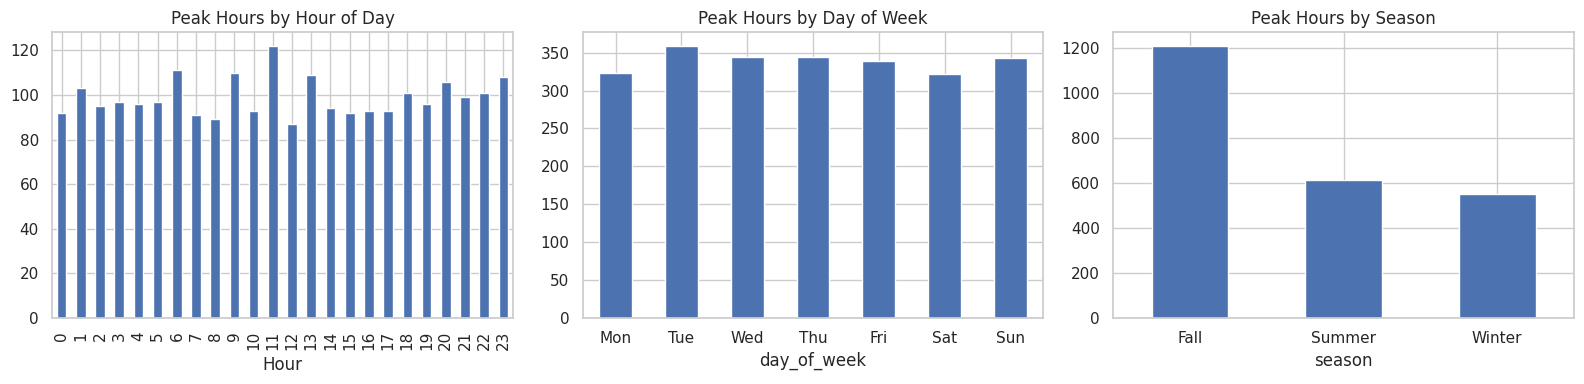

In [5]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
peaks = df[df["is_peak"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

peaks["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Peak Hours by Hour of Day")
axes[0].set_xlabel("Hour")

peaks["day_of_week"].value_counts().sort_index().reindex(range(7)).plot(kind="bar", ax=axes[1])
axes[1].set_xticklabels(dow_labels, rotation=0)
axes[1].set_title("Peak Hours by Day of Week")

peaks["season"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Peak Hours by Season")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [6]:
event_peak_rate = df.groupby(df["public_event"] >= 0.5)["is_peak"].mean()
event_peak_rate.index = ["No public event", "Public event"]
print("Share of hours that are peak hours, by public-event flag:")
event_peak_rate

Share of hours that are peak hours, by public-event flag:


No public event    0.051004
Public event       0.045704
Name: is_peak, dtype: float64

## What conditions coincide with peaks? Weather factors

Compares each weather variable's distribution during peak hours against non-peak hours. A visibly shifted distribution suggests that variable helps explain *why* a peak happened, beyond just time of day/week.

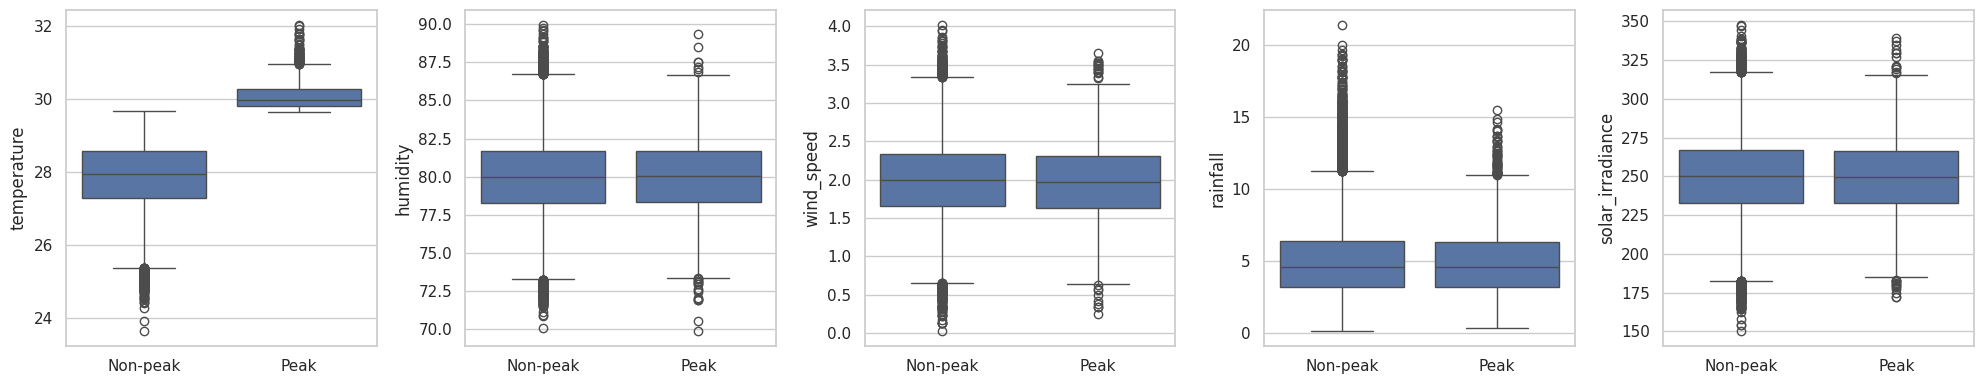

In [7]:
weather_cols = [c for c in ["temperature", "humidity", "wind_speed", "rainfall", "solar_irradiance"] if c in df.columns]
plot_df = df[weather_cols + ["is_peak"]].copy()
plot_df["is_peak"] = plot_df["is_peak"].map({True: "Peak", False: "Non-peak"})

fig, axes = plt.subplots(1, len(weather_cols), figsize=(4 * len(weather_cols), 4))
for ax, col in zip(axes, weather_cols):
    sns.boxplot(data=plot_df, x="is_peak", y=col, ax=ax)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Load each model's predictions

Same `reports/*_predictions.csv` files `10_model_comparison.ipynb` uses.

In [ ]:
PREDICTIONS_FILES = ["baseline_predictions.csv", "statistical_predictions.csv", "ml_predictions.csv", "dl_predictions.csv"]

prediction_frames = []
for filename in PREDICTIONS_FILES:
    path = REPORTS_DIR / filename
    if not path.exists():
        print(f"Skipping {filename}: not found -- run the corresponding notebook first")
        continue
    frame = pd.read_csv(path, parse_dates=["timestamp"])
    prediction_frames.append(frame)

all_predictions = pd.concat(prediction_frames, ignore_index=True).drop_duplicates(["timestamp", "model"])
print(f"Models with saved predictions: {sorted(all_predictions['model'].unique())}")

Models with saved predictions: ['ARIMA(2,1,2)', 'LSTM', 'Moving average (24h)', 'Naive (previous hour)', 'Random Forest', 'SARIMA(1,1,1)(1,1,1,24)', 'Seasonal naive (previous day)', 'Seasonal naive (previous week)', 'XGBoost']


## Peak-demand forecasting error, per model

Each prediction row is tagged with the season-specific `is_peak` flag looked up by timestamp, then MAE/RMSE/bias are computed separately for peak and non-peak hours. **Bias** is the mean of `predicted - actual`: negative means the model tends to *underestimate* peaks (the more consequential error, since it's what causes an unanticipated shortage), positive means it tends to overestimate them.

In [9]:
all_predictions = all_predictions.merge(
    df[["is_peak"]], left_on="timestamp", right_index=True, how="inner"
)

peak_results = []
for model_name, group in all_predictions.groupby("model"):
    for label, subset in [("peak", group[group["is_peak"]]), ("non-peak", group[~group["is_peak"]])]:
        if subset.empty:
            continue
        peak_results.append({
            "model": model_name,
            "period": label,
            "n_hours": len(subset),
            "mae": mae(subset["actual"].to_numpy(), subset["predicted"].to_numpy()),
            "rmse": rmse(subset["actual"].to_numpy(), subset["predicted"].to_numpy()),
            "bias": np.mean(subset["predicted"].to_numpy() - subset["actual"].to_numpy()),
        })

peak_df = pd.DataFrame(peak_results)
peak_only = peak_df[peak_df["period"] == "peak"].sort_values("mae").reset_index(drop=True)
peak_df.pivot(index="model", columns="period", values="mae").sort_values("peak")

period,non-peak,peak
model,,
Random Forest,0.028491,0.127701
XGBoost,0.951066,3.397662
Seasonal naive (previous day),107.999865,204.930673
LSTM,73.174041,205.360662
"ARIMA(2,1,2)",73.089638,205.874649
Seasonal naive (previous week),108.341295,205.918548
"SARIMA(1,1,1)(1,1,1,24)",73.097615,206.244178
Moving average (24h),74.588865,206.878722
Naive (previous hour),108.471456,219.397083


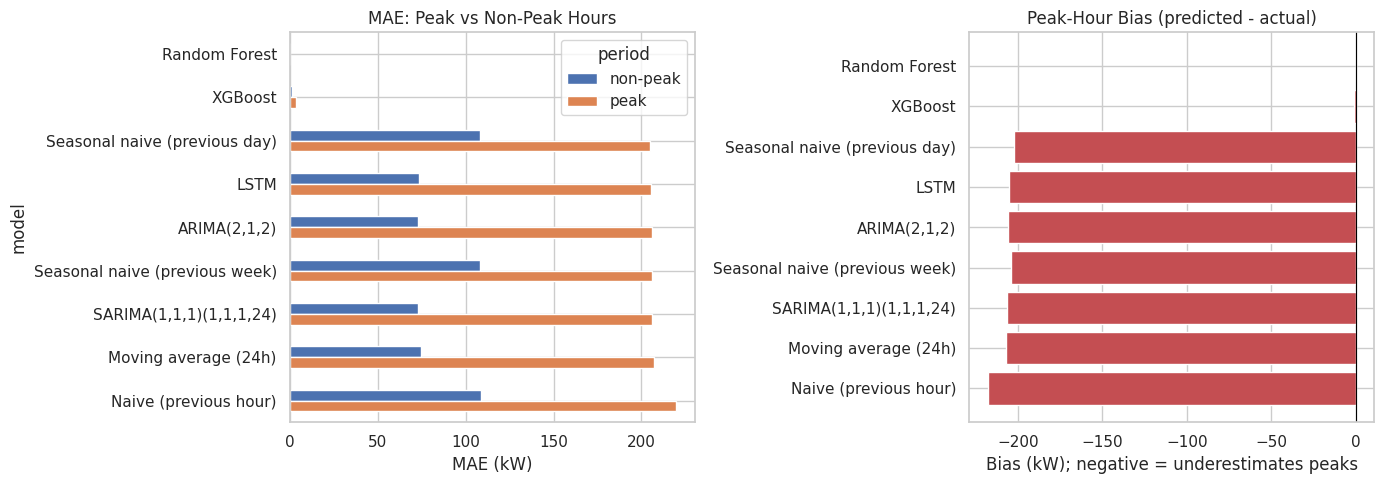

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_mae = peak_df.pivot(index="model", columns="period", values="mae").loc[peak_only["model"]]
pivot_mae.plot(kind="barh", ax=axes[0])
axes[0].set_title("MAE: Peak vs Non-Peak Hours")
axes[0].set_xlabel("MAE (kW)")
axes[0].invert_yaxis()

axes[1].barh(peak_only["model"], peak_only["bias"], color=["C3" if b < 0 else "C0" for b in peak_only["bias"]])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Peak-Hour Bias (predicted - actual)")
axes[1].set_xlabel("Bias (kW); negative = underestimates peaks")
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "peak_demand_seasonal_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Best model: actual vs predicted at peak hours

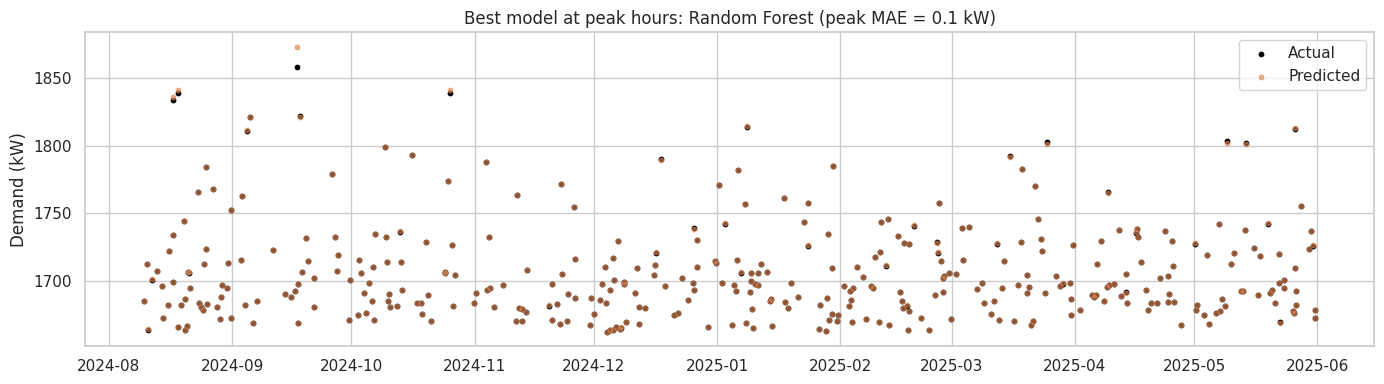

In [11]:
best_model = peak_only.iloc[0]["model"]
best_peaks = all_predictions[(all_predictions["model"] == best_model) & (all_predictions["is_peak"])].sort_values("timestamp")

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(best_peaks["timestamp"], best_peaks["actual"], s=10, label="Actual", color="black")
ax.scatter(best_peaks["timestamp"], best_peaks["predicted"], s=10, label="Predicted", alpha=0.6, color="C1")
ax.set_title(f"Best model at peak hours: {best_model} (peak MAE = {peak_only.iloc[0]['mae']:.1f} kW)")
ax.set_ylabel("Demand (kW)")
ax.legend()
plt.tight_layout()
plt.show()

## Save results

In [ ]:
PEAK_PATH = REPORTS_DIR / "peak_demand_seasonal_comparison.csv"
peak_df.to_csv(PEAK_PATH, index=False)

THRESHOLDS_PATH = REPORTS_DIR / "peak_demand_seasonal_thresholds.csv"
season_thresholds.rename("threshold").to_csv(THRESHOLDS_PATH)

print(f"Saved per-model peak/non-peak comparison to {PEAK_PATH}")
print(f"Saved seasonal thresholds to {THRESHOLDS_PATH}")

Saved per-model peak/non-peak comparison to /kaggle/working/reports/peak_demand_seasonal_comparison.csv
Saved seasonal thresholds to /kaggle/working/reports/peak_demand_seasonal_thresholds.csv
